In [18]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

In [19]:
# --- 1. ROBUST DATASET: Lazy Loading with File Filtering ---
class IntelDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        # Filter for valid subdirectories and images only
        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        
        valid_ext = ('.jpg', '.jpeg', '.png')
        for cls in classes:
            folder = os.path.join(root_dir, cls)
            for img_name in os.listdir(folder):
                if img_name.lower().endswith(valid_ext):
                    self.image_paths.append(os.path.join(folder, img_name))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform: img = self.transform(img)
        return img, label

In [ ]:
dataset_path = r'E:\ITI\CONTENT\Deep learning\Day 3\intel_data\seg_train\seg_train' 
transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
train_set = IntelDataset(dataset_path, transform=transform)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

In [21]:
# --- 2. MODEL DEFINITIONS ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Linear(64 * 14 * 14, 6) # Adjusted for 64x64
    def forward(self, x):
        return self.classifier(torch.flatten(self.features(x), 1))

In [33]:
def train_model(model, loader, epochs=3):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    # Initialize the dictionary to store performance metrics
    history = {'loss': []} 
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        # Calculate the average loss for this epoch
        epoch_loss = running_loss / len(loader)
        history['loss'].append(epoch_loss)
        print(f"Epoch {epoch+1} finished. Average Loss: {epoch_loss:.4f}")
    
    # Return the history so it can be used for plotting
    return history

In [23]:
# --- 4. VISUALIZATION ---
def visualize_filters(model):
    weights = list(model.parameters())[0].data.cpu()
    plt.figure(figsize=(10, 2))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(weights[i].permute(1, 2, 0).numpy())
        plt.axis('off')
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1887749..0.1722012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17972545..0.17897345].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19099608..0.18588986].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17714013..0.18188767].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1853128..0.18829058].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17300823..0.18145888].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [

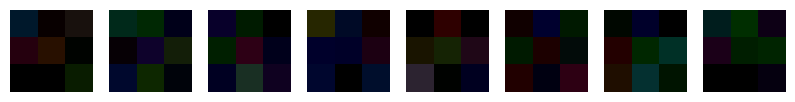

Epoch 1 finished. Loss: 1.0318
Epoch 2 finished. Loss: 0.7957


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19871706..0.19296756].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21302687..0.17825378].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24393353..0.1999701].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20337139..0.17141551].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24640672..0.22389486].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17460126..0.20523027].


Epoch 3 finished. Loss: 0.6863


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23795752..0.20758365].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19153549..0.24951176].


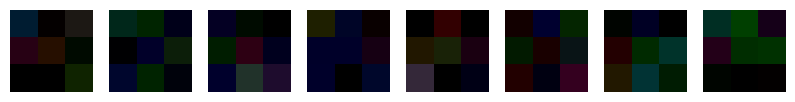

In [24]:
# Execution
model = SimpleCNN()
visualize_filters(model) # Before
train_model(model, train_loader)
visualize_filters(model) # After

In [ ]:
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
# Replace the final layer for 6 classes
model.fc = nn.Linear(model.fc.in_features, 6)

Epoch 1 finished. Average Loss: 0.9056
Epoch 2 finished. Average Loss: 0.7208
Epoch 3 finished. Average Loss: 0.7004


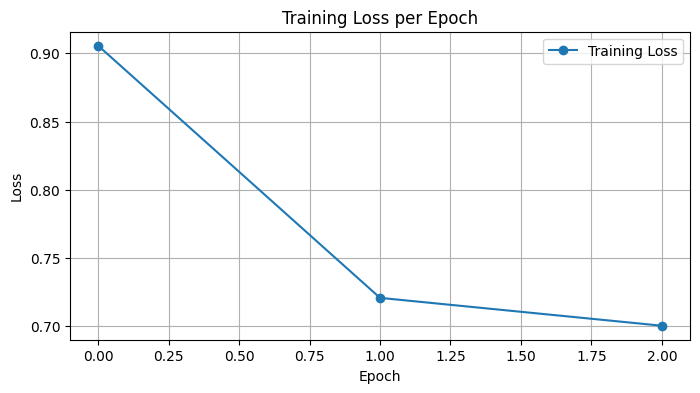

In [36]:
plt.figure(figsize=(8, 4))
history = train_model(model, train_loader, epochs=3)
plt.plot(history['loss'], marker='o', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

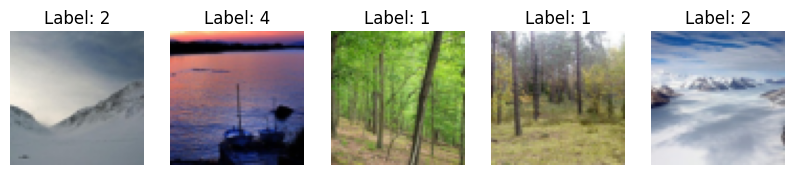

In [ ]:
# Display a few images from the loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Convert tensor back to image format
    img = images[i].permute(1, 2, 0) 
    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()

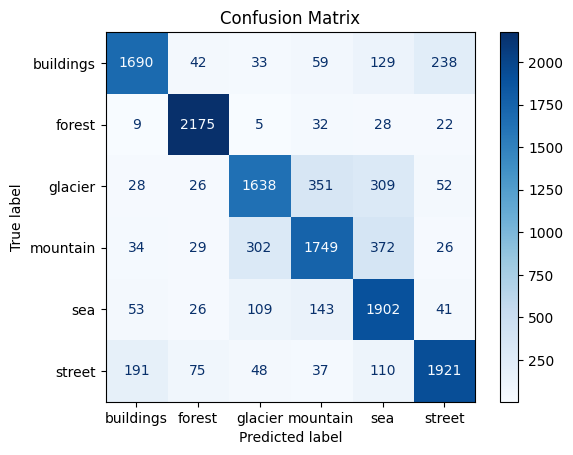

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, loader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(y.numpy())
            y_pred.extend(predicted.numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
plot_confusion_matrix(model, train_loader, classes)